In [40]:
import os
os.chdir('../')

from data_class import Data
import pandas as pd
import numpy as np

files = [
        "2026-07-30_E_e.csv"]

dfs = []

for file in files:
    data = Data(file)
    dfs.append(data.data)

result = pd.concat(dfs, ignore_index=True)
# result.sort_values(by='time', inplace=True)
# result.dropna(inplace=True)


f:\Data\2026\*\*\*\2026-07-30_E_e.csv


In [41]:
yname = "G.nfit"

y = result[yname]
x = result["time"]

def linear_fit(x, m, b):
    return m*x + b

p0 = [1,1000]

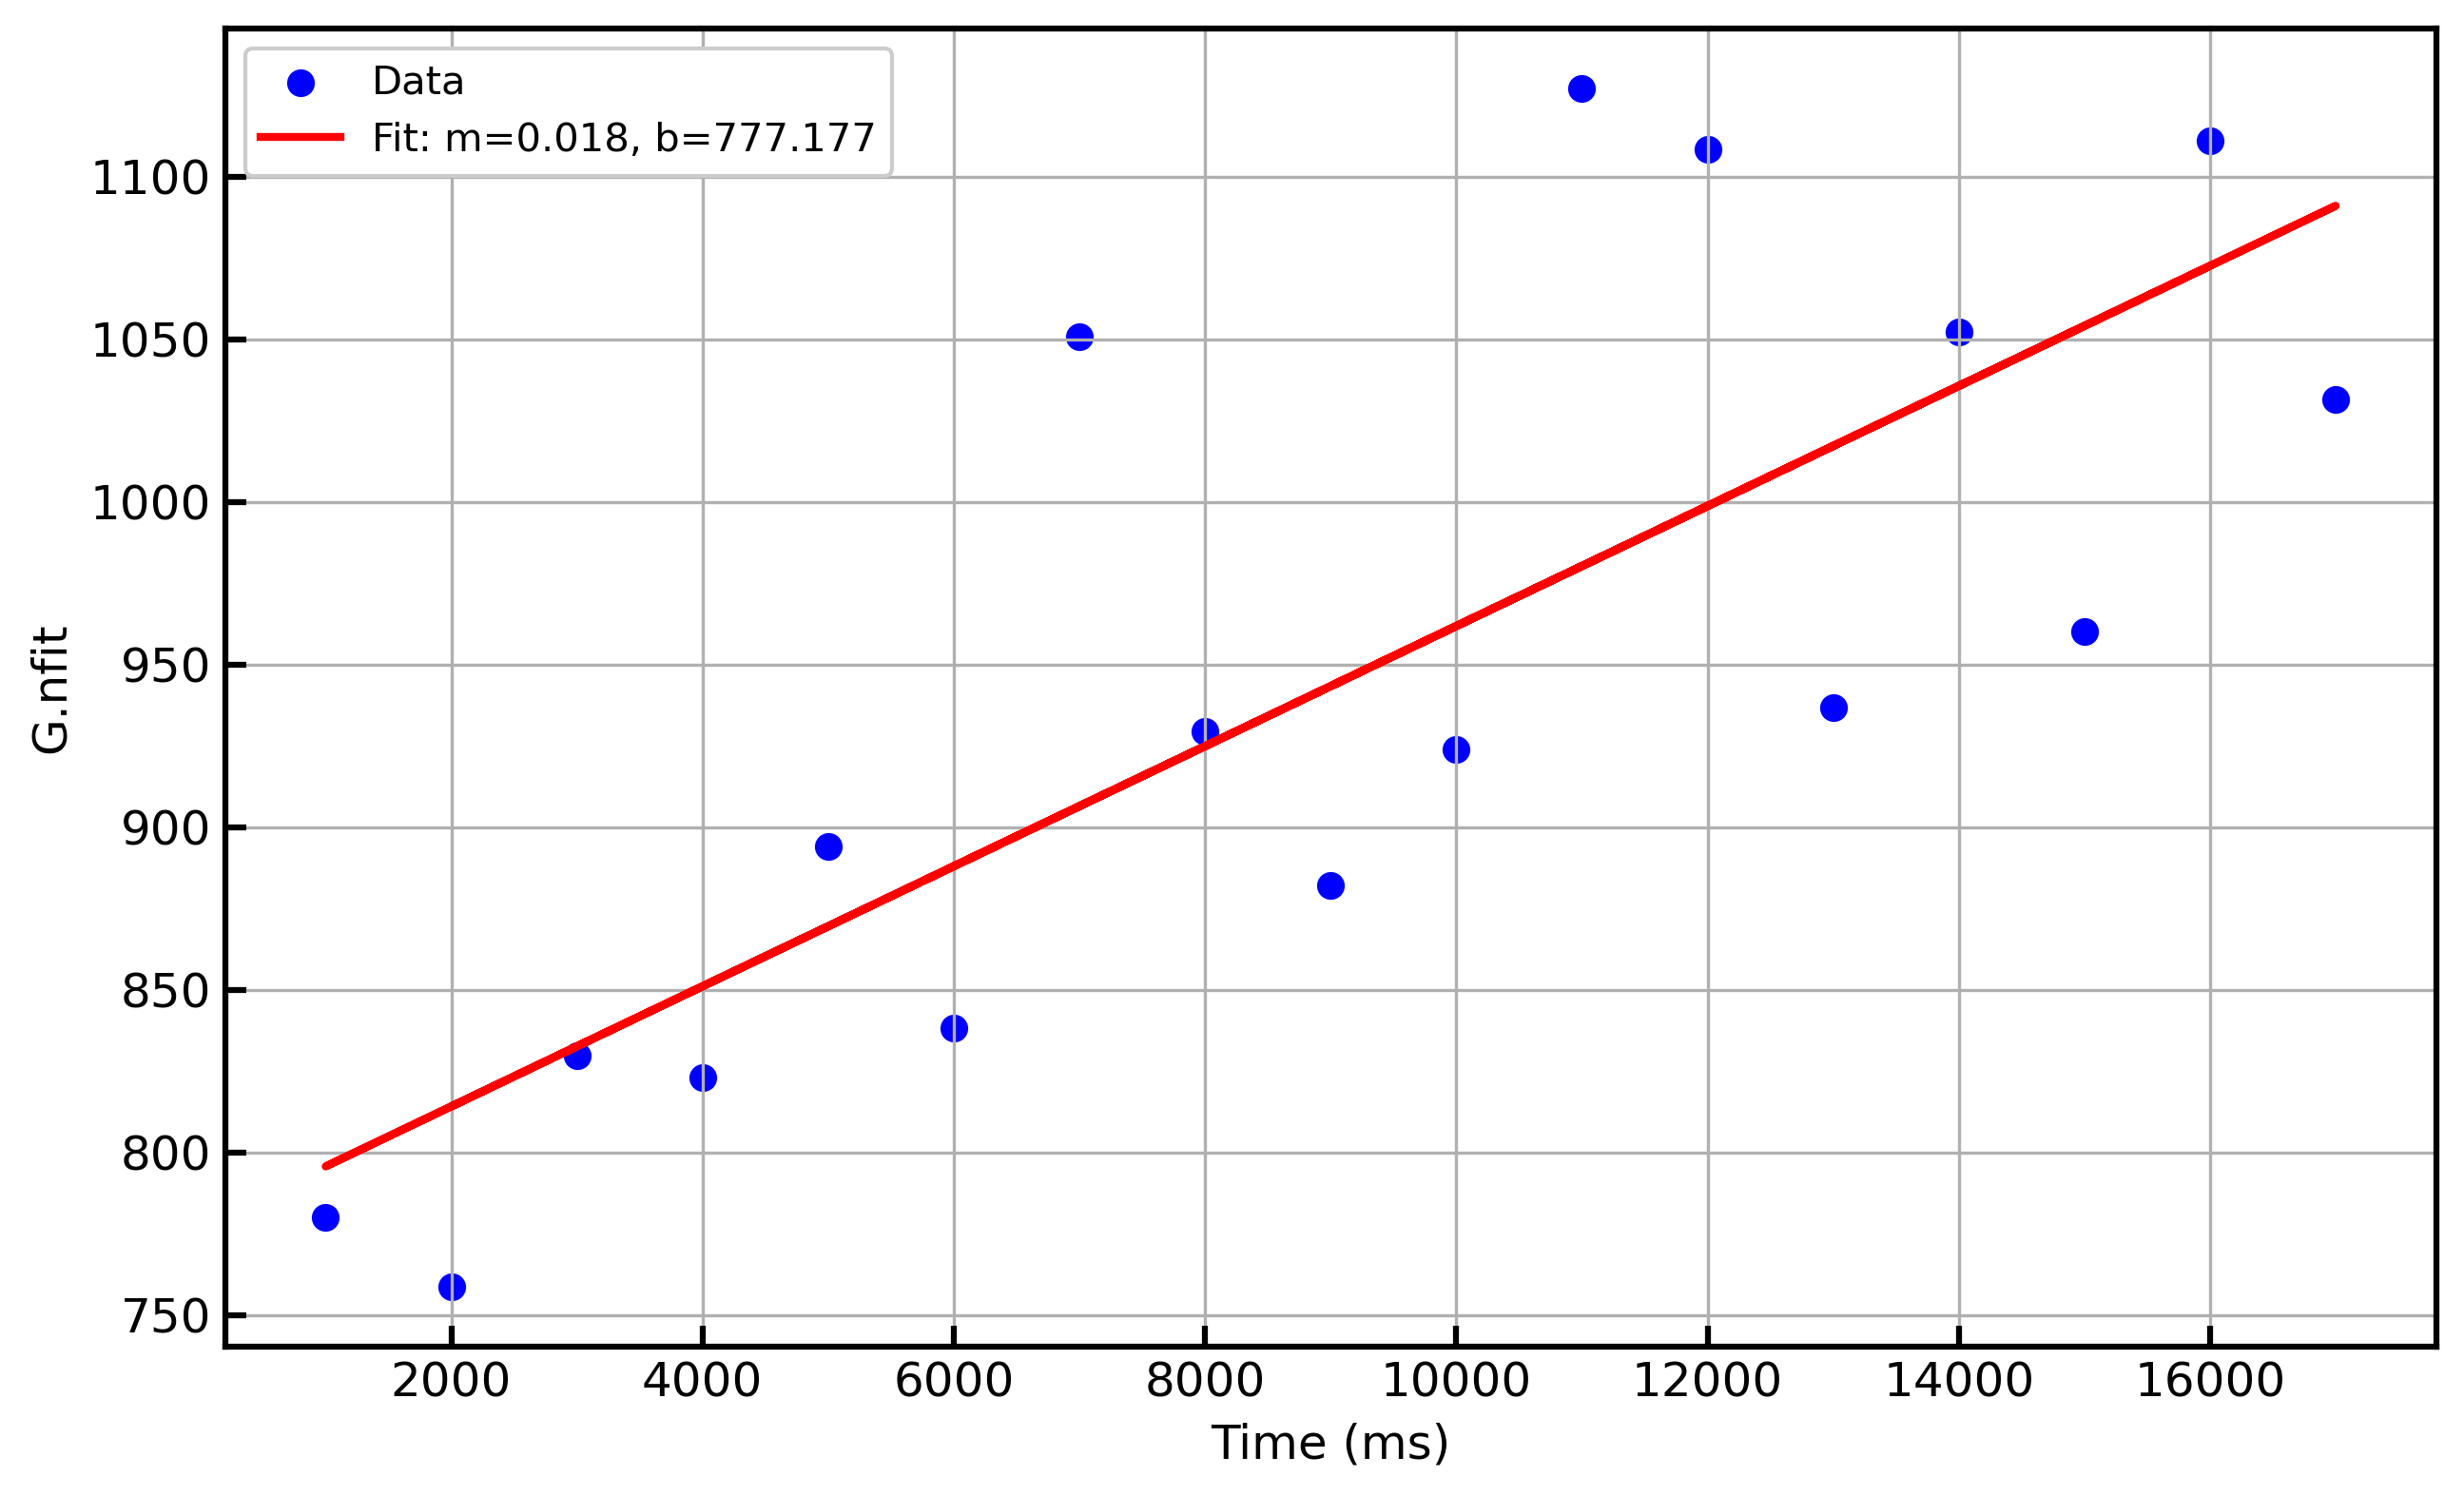

In [42]:
import matplotlib.pyplot as plt

# x = x[:-9]
# y = y[:-9]
from scipy.optimize import curve_fit
popt, pcov = curve_fit(linear_fit, x, y, p0=p0)
perr = np.sqrt(np.diag(pcov))
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data', color='blue')
# x_fit = np.linspace(x.min(), x.max(), 1000)
plt.plot(x, linear_fit(x, *popt), '-', label=f"Fit: m={popt[0]:.3f}, b={popt[1]:.3f}", color='red')
plt.xlabel('Time (ms)')
plt.ylabel(f'{yname}')
plt.legend()
plt.grid()


[1.8460360e-02 7.7717742e+02]
[4.45728188e-01 1.79961244e+04]


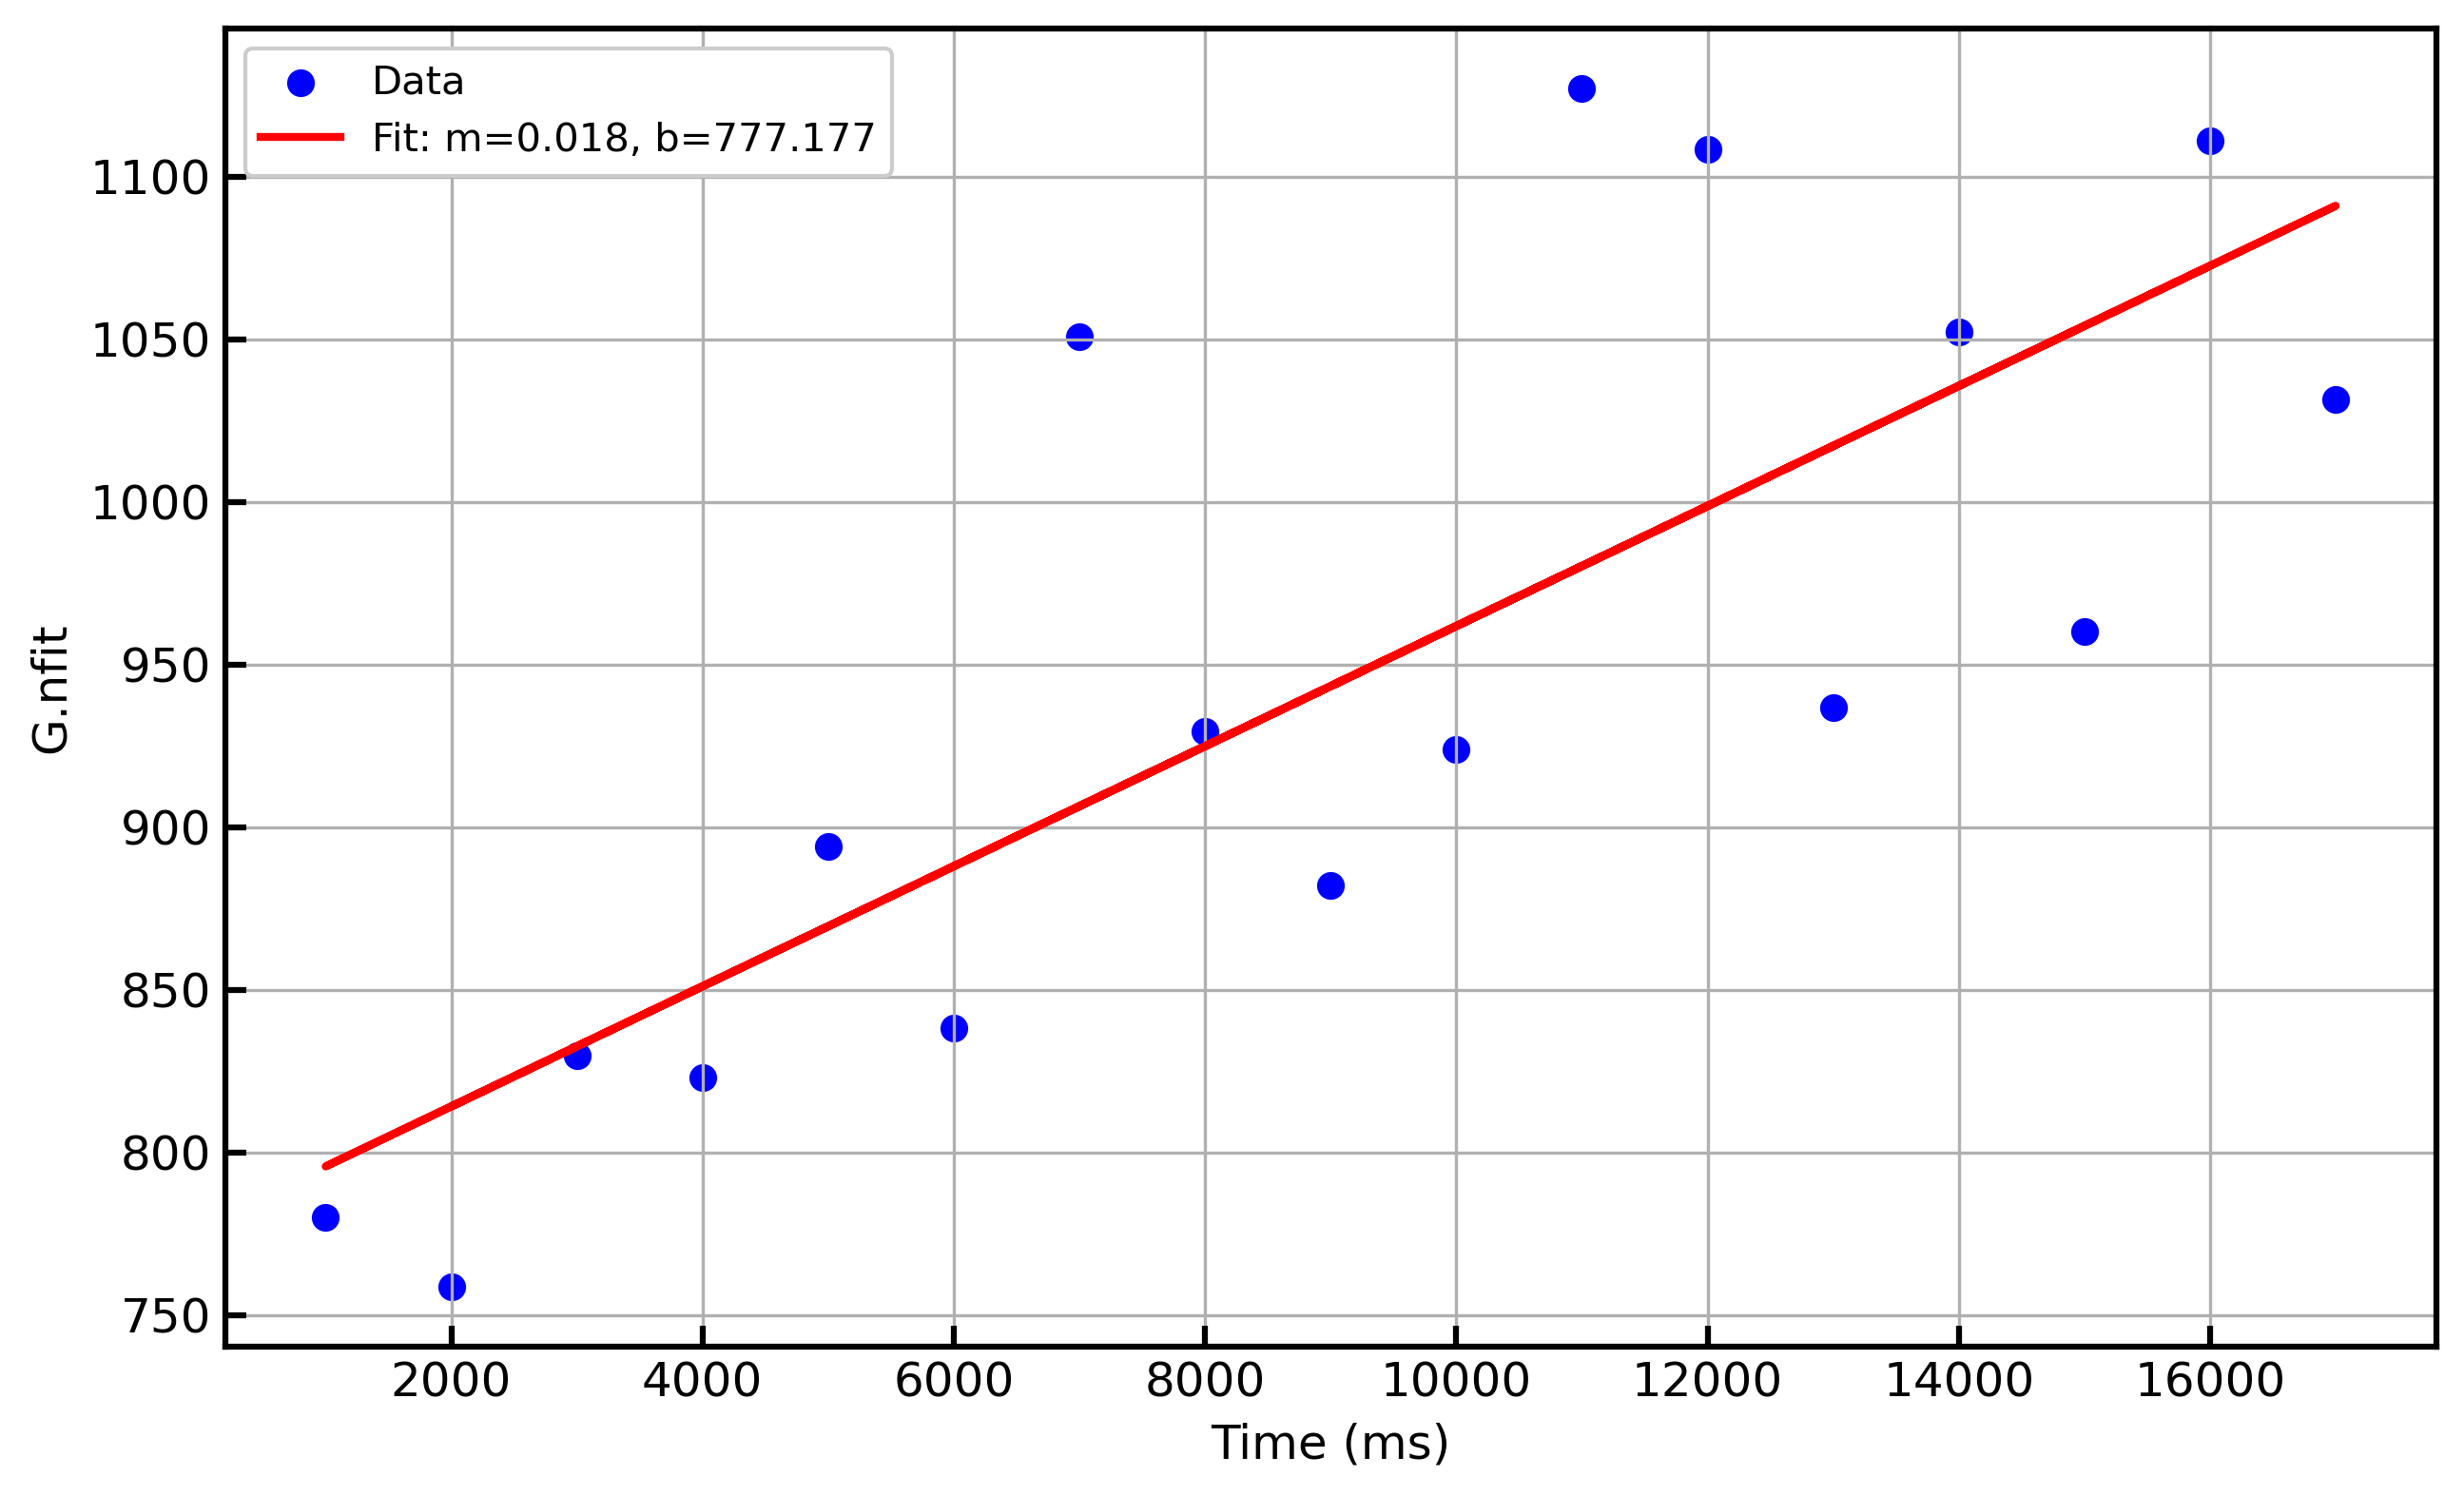

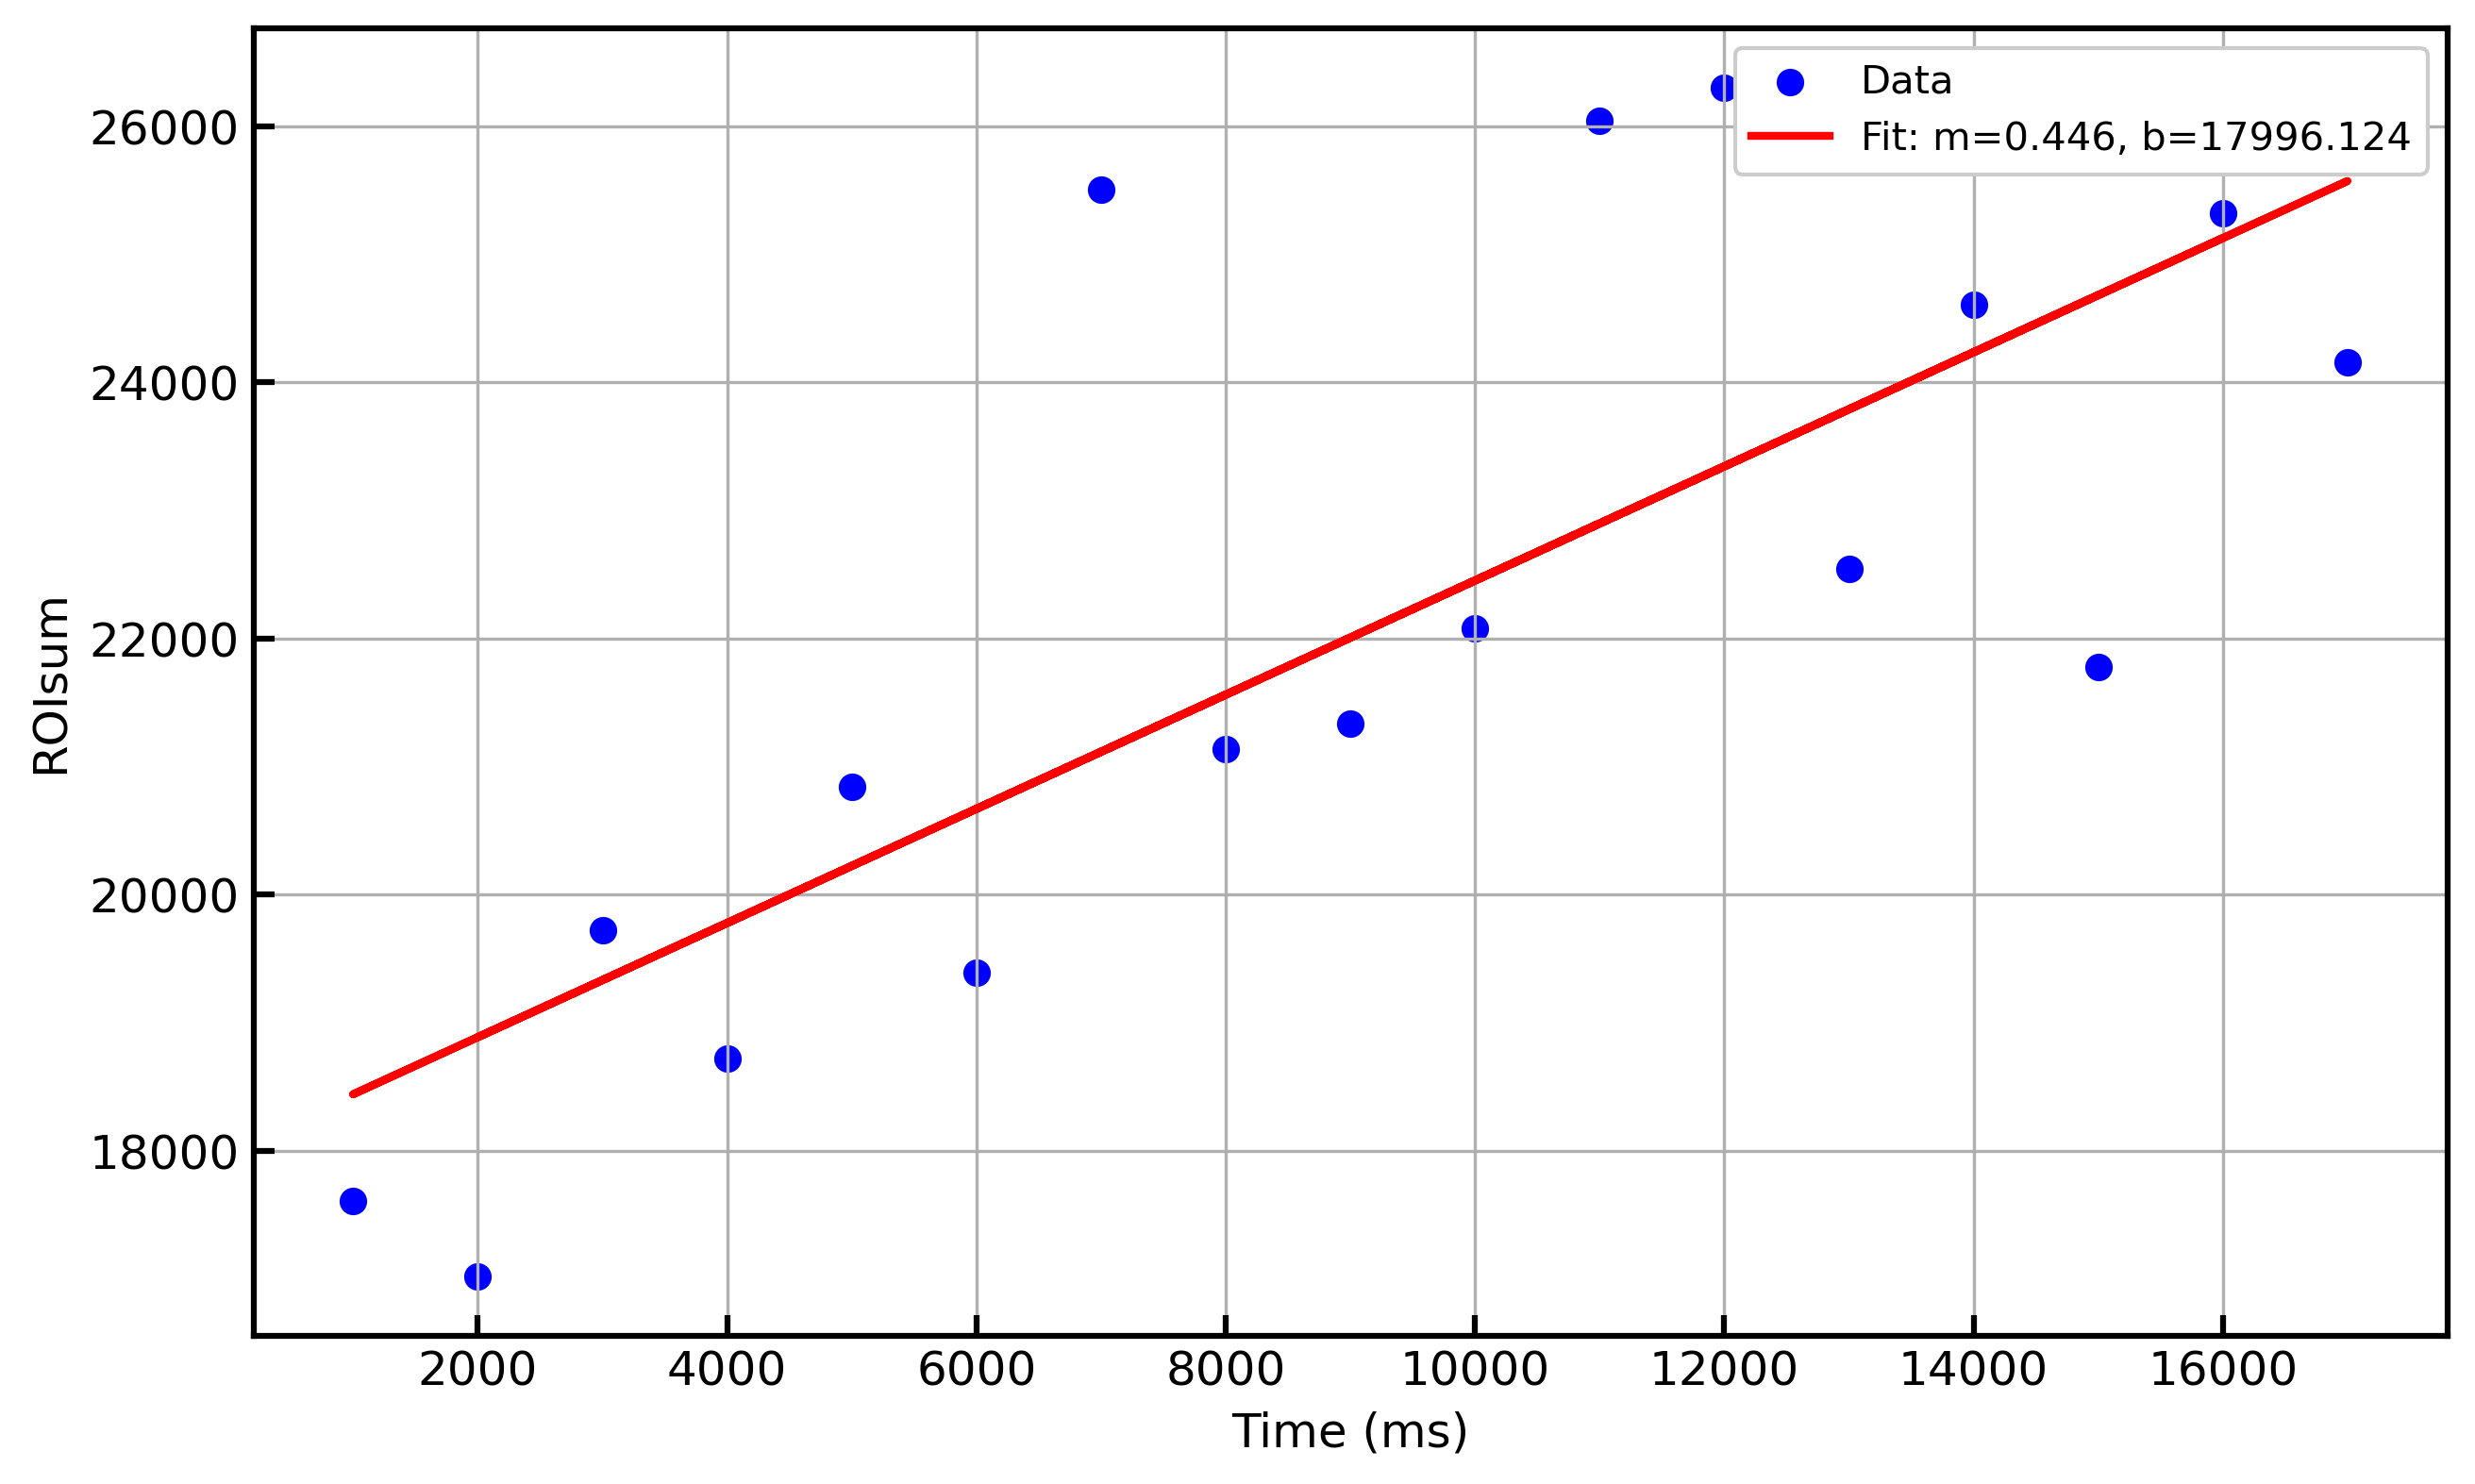

In [43]:
ynames = ["G.nfit","ROIsum"]

for y_name in ynames:
    y = result[y_name]
    popt, pcov = curve_fit(linear_fit, x, y, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label='Data', color='blue')
    # x_fit = np.linspace(x.min(), x.max(), 1000)
    plt.plot(x, linear_fit(x, *popt), '-', label=f"Fit: m={popt[0]:.3f}, b={popt[1]:.3f}", color='red')
    plt.xlabel('Time (ms)')
    plt.ylabel(f'{y_name}')
    plt.legend()
    plt.grid()

    print(popt)